# LEP-i partial velocity・温度・圧力の検証：ドリフトMaxwell分布

目的は、既知の真のバルク速度を持つ$\mathrm{H}^{+}$分布から $30\,\mathrm{eV}\le E\le30\,\mathrm{keV}$ のmomentを取り、速度・温度・圧力の偏りを定量化すること。既存の `statistical_analysis_arase` を変更せずに行う、連続速度空間での基準計算である。

- 等方的な単一ドリフトMaxwell分布、全立体角、$\mathrm{H}^{+}$のみを扱う。$\mathrm{H}^{+}$では eV と eV/q の数値は一致する。
- **流速 $\mathbf{U}$ は、エネルギー選択 $E = m_{\mathrm{p}} |\mathbf{v}|^{2}/2$ を行う座標系で定義する。** プラズマ静止系でエネルギーを切る計算ではない。観測と比較する際は、関数の座標系と衛星速度補正の仕様を別途確認する。
- 衛星電位、検出効率、角度欠測、実際のエネルギー・角度ビン、計数統計、時間平均、多成分分布は含めない。
- `erg_lep_part_products` 自体は呼ばない。その実装・ビン積分の検証は次の段階になる。
- 温度・流速の走査範囲は挙動確認用であり、注目するtime rangeに妥当だと確認された範囲ではない。

上から全セルを実行する。計算結果・図は、このノートと同じディレクトリの `outputs/` に保存する。

## 定義と積分

温度に相当するエネルギーを $\theta=k_{\mathrm{B}}T$ とし、入力では eV 単位で指定する。熱速度は

$$
v_{\mathrm{th}}=\sqrt{\frac{2\theta}{m_{\mathrm{p}}}}
$$

で定義する。速度を SI 単位で計算する際は、$\theta$ を eV から J に変換する。コード中では `theta_ev * elementary_charge` がこの変換に対応する。

ドリフト速度を $\mathbf{U}=U\hat{\mathbf{z}}$（$U\ge0$）とすると、分布関数は

$$
f(\mathbf{v})=
\frac{n}{\pi^{3/2}v_{\mathrm{th}}^{3}}
\exp\!\left[-\frac{|\mathbf{v}-U\hat{\mathbf{z}}|^{2}}{v_{\mathrm{th}}^{2}}\right].
$$

選択する速度空間と、その領域内の密度・平均速度を

$$
D=\left\{\mathbf{v}\ \middle|\ E_{\min}\le\frac{m_{\mathrm{p}}|\mathbf{v}|^{2}}{2}\le E_{\max}\right\},
\qquad
n_D=\int_D f(\mathbf{v})\,\mathrm{d}^{3}v,
\qquad
U_D=\frac{\int_D v_z f(\mathbf{v})\,\mathrm{d}^{3}v}{n_D}
$$

とする。球殻状の選択領域と分布の軸対称性により、ドリフト軸に垂直な平均速度はゼロになる。ここで $z$ はドリフト方向であり、磁場方向を意味しない。

無次元変数を

$$
x=\frac{|\mathbf{v}|}{v_{\mathrm{th}}},\qquad
a=\frac{U}{v_{\mathrm{th}}},\qquad
\mu=\hat{\mathbf{v}}\cdot\hat{\mathbf{z}},\qquad
x_{\min}=\sqrt{\frac{E_{\min}}{\theta}},\qquad
x_{\max}=\sqrt{\frac{E_{\max}}{\theta}}
$$

と定義する。$E_{\min}$、$E_{\max}$、$\theta$ は同じエネルギー単位を用いる。角度積分を解析的に行い、半径方向のみ数値積分する。

$$
\begin{aligned}
A_0(x,a)&=\int_{-1}^{1}\exp(-x^{2}-a^{2}+2xa\mu)\,\mathrm{d}\mu,\\
A_1(x,a)&=\int_{-1}^{1}\mu\exp(-x^{2}-a^{2}+2xa\mu)\,\mathrm{d}\mu.
\end{aligned}
$$

これにより、求める密度回収率と平均速度は

$$
\frac{n_D}{n}=\frac{2}{\sqrt{\pi}}
\int_{x_{\min}}^{x_{\max}}x^{2}A_0(x,a)\,\mathrm{d}x,
\qquad
\frac{U_D}{v_{\mathrm{th}}}=
\frac{\displaystyle\int_{x_{\min}}^{x_{\max}}x^{3}A_1(x,a)\,\mathrm{d}x}
{\displaystyle\int_{x_{\min}}^{x_{\max}}x^{2}A_0(x,a)\,\mathrm{d}x}
$$

となる。$b=2xa>0$ に対しては、数値的に安定な形として

$$
A_0(x,a)=\exp[-(x-a)^{2}]\frac{1-\exp(-2b)}{b},
\qquad
A_1(x,a)=A_0(x,a)\left(\coth b-\frac{1}{b}\right)
$$

を使う。$b=0$ では $A_0=2\exp(-x^{2}-a^{2})$、$A_1=0$ とする。$b$ が小さい場合には、$\coth b-1/b=b/3-b^{3}/45+2b^{5}/945+\mathcal{O}(b^{7})$ を使い、桁落ちを避ける。速度比 $U_D/U$ は $U=0$ では定義しない。


In [1]:
from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import scipy
from scipy.integrate import quad
from scipy.constants import proton_mass, elementary_charge
from numpy.polynomial.legendre import leggauss
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

OUTPUT_DIR = Path.cwd() / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
print('Python:', sys.version.split()[0], '|', platform.platform())
print('NumPy:', np.__version__, 'SciPy:', scipy.__version__,
      'pandas:', pd.__version__, 'Matplotlib:', matplotlib.__version__)
print('Output directory:', OUTPUT_DIR)


Python: 3.12.3 | Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
NumPy: 2.5.3 SciPy: 1.18.1 pandas: 3.0.5 Matplotlib: 3.11.2
Output directory: /home/satanka/Documents/observation_workspace/lepi_partial_moment_validation/outputs


In [2]:
# θ = k_B T [eV], U [km/s]. U >= 0 を指定する。
ENERGY_MIN_EV = 30.0
ENERGY_MAX_EV = 30_000.0
DENSITY_FLOOR = 1e-10  # 回収率がこれ以下なら速度比を解釈しない
TEMPERATURES_EV = np.geomspace(1.0, 1e4, 51)
SPEEDS_KMS = np.linspace(0.0, 300.0, 61)

# x > a + 12 は exp[-(x-a)^2] <= exp(-144) の裾になる。
# ここを打ち切る。通常の許容誤差に対して十分小さいことを収束試験で確認する。
TAIL_WIDTH = 12.0
EPSABS = 1e-15
EPSREL = 2e-9


In [3]:
def angular_moments(x, a):
    """安定化した解析的角度積分 A0, A1。x, a >= 0。"""
    b = 2.0 * x * a
    if b == 0.0:
        return 2.0 * np.exp(-x*x - a*a), 0.0
    a0 = np.exp(-(x-a)**2) * (-np.expm1(-2.0*b)) / b
    if b < 1e-3:
        langevin = b/3.0 - b**3/45.0 + 2.0*b**5/945.0
    else:
        langevin = 1.0/np.tanh(b) - 1.0/b
    return a0, a0*langevin


def partial_moment(theta_ev, speed_kms, emin_ev=ENERGY_MIN_EV,
                   emax_ev=ENERGY_MAX_EV, *, epsabs=EPSABS,
                   epsrel=EPSREL, tail_width=TAIL_WIDTH):
    """n_D/n, U_D [km/s], 積分誤差の推定値を返す。絶対密度は不要。"""
    if not np.isfinite(theta_ev) or theta_ev <= 0:
        raise ValueError('theta_ev must be finite and positive')
    if not np.isfinite(speed_kms) or speed_kms < 0:
        raise ValueError('speed_kms must be finite and nonnegative')
    if not np.isfinite(emin_ev) or emin_ev < 0 or not emax_ev > emin_ev:
        raise ValueError('Require 0 <= emin_ev < emax_ev')
    if not np.isfinite(tail_width) or tail_width <= 0:
        raise ValueError('tail_width must be finite and positive')
    vth_kms = np.sqrt(2.0*theta_ev*elementary_charge/proton_mass)/1000.0
    a = speed_kms/vth_kms
    lo = np.sqrt(emin_ev/theta_ev)
    hi = min(np.sqrt(emax_ev/theta_ev), a + tail_width)
    if lo >= hi:
        return dict(density_fraction=0.0, partial_speed_kms=np.nan,
                    density_quad_error=0.0, flux_quad_error=0.0)
    # ピーク周辺の区切りを明示し、広い積分区間でも分布を見落とさない。
    points = sorted({float(t) for t in [1.0, a-6, a-3, a-1, a, a+1, a+3, a+6]
                     if lo < t < hi})
    opts = dict(epsabs=epsabs, epsrel=epsrel, limit=200, points=points)
    norm = 2.0/np.sqrt(np.pi)
    nd, nd_err = quad(lambda x: norm*x*x*angular_moments(x, a)[0], lo, hi, **opts)
    flux, flux_err = quad(lambda x: norm*x**3*angular_moments(x, a)[1], lo, hi, **opts)
    ud = vth_kms*flux/nd if nd > DENSITY_FLOOR else np.nan
    return dict(density_fraction=nd, partial_speed_kms=ud,
                density_quad_error=nd_err, flux_quad_error=flux_err)


## 数値計算の検算

全速度空間で密度回収率1・平均速度 $U$が戻ること、$U=0$で平均速度ゼロとなること、解析的角度積分と独立の2次元Gauss–Legendre積分が一致することを調べる。さらに積分許容誤差と裾の打切り位置を変えて収束を確認する。`quad` の誤差推定は積分誤差であり、モデルの不確実性を表さない。

In [4]:
def independent_2d_moment(theta_ev, speed_kms, order=192):
    """角度も数値積分する独立な検算。moderate drift のケースに使用。"""
    vth = np.sqrt(2*theta_ev*elementary_charge/proton_mass)/1000
    a = speed_kms/vth
    lo = np.sqrt(ENERGY_MIN_EV/theta_ev)
    hi = min(np.sqrt(ENERGY_MAX_EV/theta_ev), a+TAIL_WIDTH)
    nodes, weights = leggauss(order)
    x = (hi-lo)/2*nodes + (hi+lo)/2
    wx = (hi-lo)/2*weights
    mu = nodes
    expo = np.exp(-(x[:, None]-a)**2 - 2*x[:, None]*a*(1-mu[None, :]))
    measures = wx[:, None]*weights[None, :]*x[:, None]**2*expo
    nd = 2/np.sqrt(np.pi)*measures.sum()
    flux = 2/np.sqrt(np.pi)*(measures*x[:, None]*mu[None, :]).sum()
    return nd, vth*flux/nd

check_rows = []
for theta, speed in [(1., 300.), (10., 0.), (100., 50.), (1000., 300.), (1e4, 50.)]:
    full = partial_moment(theta, speed, 0., np.inf)
    np.testing.assert_allclose(full['density_fraction'], 1., rtol=2e-8, atol=1e-12)
    np.testing.assert_allclose(full['partial_speed_kms'], speed, rtol=2e-8, atol=1e-8)
    check_rows.append(dict(check='full domain', theta_ev=theta, U_kms=speed,
                           density_fraction=full['density_fraction'], U_D_kms=full['partial_speed_kms']))
for theta in [1., 10., 100., 1000., 1e4]:
    r = partial_moment(theta, 0.)
    if r['density_fraction'] > DENSITY_FLOOR:
        assert r['partial_speed_kms'] == 0.
for theta, speed in [(10., 20.), (100., 50.), (1000., 200.)]:
    r = partial_moment(theta, speed)
    nd2, ud2 = independent_2d_moment(theta, speed)
    np.testing.assert_allclose(nd2, r['density_fraction'], rtol=1e-8, atol=1e-12)
    np.testing.assert_allclose(ud2, r['partial_speed_kms'], rtol=1e-8, atol=1e-8)
    check_rows.append(dict(check='independent 2D', theta_ev=theta, U_kms=speed,
                           density_fraction=nd2, U_D_kms=ud2))
for theta, speed in [(1., 20.), (10., 20.), (100., 50.), (1e4, 300.)]:
    normal = partial_moment(theta, speed)
    strict = partial_moment(theta, speed, epsabs=1e-17, epsrel=1e-11, tail_width=16.)
    np.testing.assert_allclose(normal['density_fraction'], strict['density_fraction'], rtol=1e-7, atol=1e-13)
    np.testing.assert_allclose(normal['partial_speed_kms'], strict['partial_speed_kms'], rtol=1e-7, atol=1e-8, equal_nan=True)
checks = pd.DataFrame(check_rows)
display(checks)
checks.to_csv(OUTPUT_DIR/'numerical_checks.csv', index=False)
print('All numerical checks passed.')


,check,theta_ev,U_kms,density_fraction,U_D_kms
0,full domain,1.0,300.0,1.000000,300.000000
1,full domain,10.0,0.0,1.000000,0.000000
2,full domain,100.0,50.0,1.000000,50.000000
3,full domain,1000.0,300.0,1.000000,300.000000
4,full domain,10000.0,50.0,1.000000,50.000000
5,independent 2D,10.0,20.0,0.152985,46.305662
6,independent 2D,100.0,50.0,0.907721,54.496626
7,independent 2D,1000.0,200.0,0.996876,200.619178


All numerical checks passed.


## 温度・流速に対する偏り

密度回収率、速度差 $U_D-U$、速度比 $U_D/U$ を表示する。速度差は入力ドリフト方向の符号付き差である。密度回収率 $n_D/n\le$ `DENSITY_FLOOR` の速度と $U=0$ の速度比は NaN とし、図では灰色にする。小さい回収率での速度比だけを、観測可能性の証拠として解釈しない。

3111 parameter combinations saved.


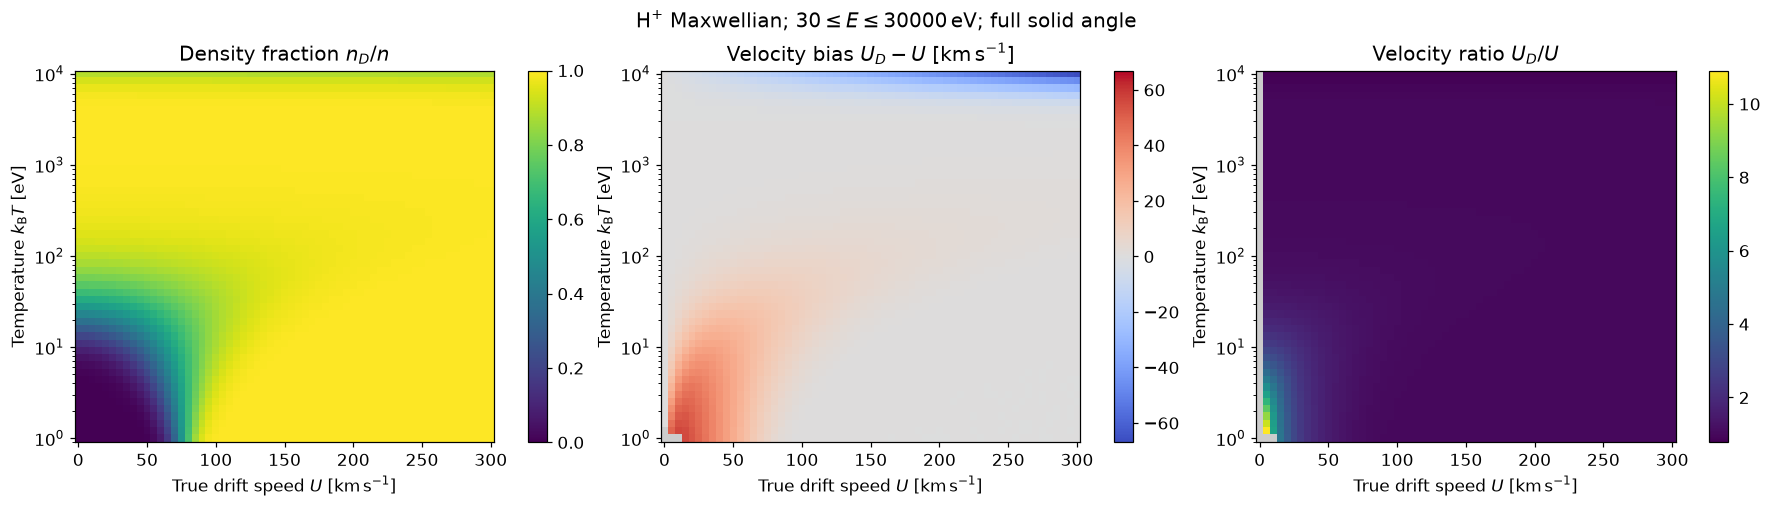

In [5]:
rows = []
for theta in TEMPERATURES_EV:
    for speed in SPEEDS_KMS:
        r = partial_moment(theta, speed)
        ud = r['partial_speed_kms']
        rows.append(dict(theta_ev=theta, true_speed_kms=speed, **r,
                         speed_bias_kms=ud-speed,
                         speed_ratio=ud/speed if speed > 0 else np.nan))
results = pd.DataFrame(rows)
results.to_csv(OUTPUT_DIR/'parameter_scan.csv', index=False)
print(f'{len(results)} parameter combinations saved.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
fields = [('density_fraction', r'Density fraction $n_D/n$', 'viridis', 0., 1.),
          ('speed_bias_kms', r'Velocity bias $U_D-U$ [$\mathrm{km\,s^{-1}}$]', 'coolwarm', None, None),
          ('speed_ratio', r'Velocity ratio $U_D/U$', 'viridis', None, None)]
for ax, (field, title, cmap_name, vmin, vmax) in zip(axes, fields):
    grid = results.pivot(index='theta_ev', columns='true_speed_kms', values=field)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('0.8')
    if field == 'speed_bias_kms':
        lim = np.nanmax(np.abs(grid.to_numpy()))
        vmin, vmax = -lim, lim
    im = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), shading='nearest',
                       cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_yscale('log')
    ax.set_xlabel(r'True drift speed $U$ [$\mathrm{km\,s^{-1}}$]')
    ax.set_ylabel(r'Temperature $k_{\mathrm{B}}T$ [$\mathrm{eV}$]')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
fig.suptitle(rf'$\mathrm{{H}}^{{+}}$ Maxwellian; ${ENERGY_MIN_EV:g} \leq E \leq {ENERGY_MAX_EV:g}\,\mathrm{{eV}}$; full solid angle')
fig.savefig(OUTPUT_DIR/'parameter_scan.png', dpi=180)
plt.show()


## 代表的な断面と積分下限への感度

以下の断面は、走査結果を読みやすくするための例である。積分下限を下げたときの変化は、このモデル内の感度を示す。実データでは下限を下げても未観測成分を取り戻せるとは限らない。上限の有限性は残るため、下限ゼロだけでは全速度空間にならない。

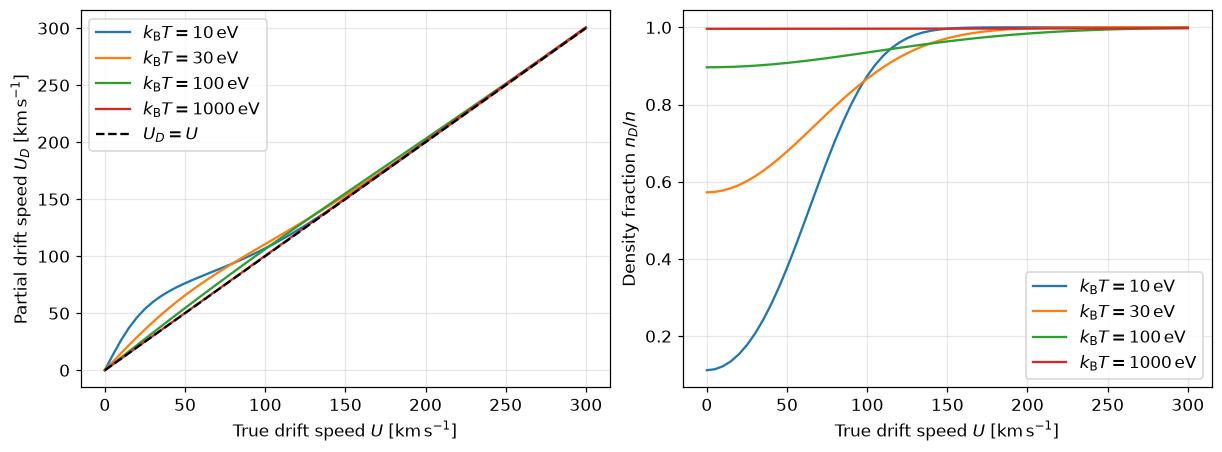

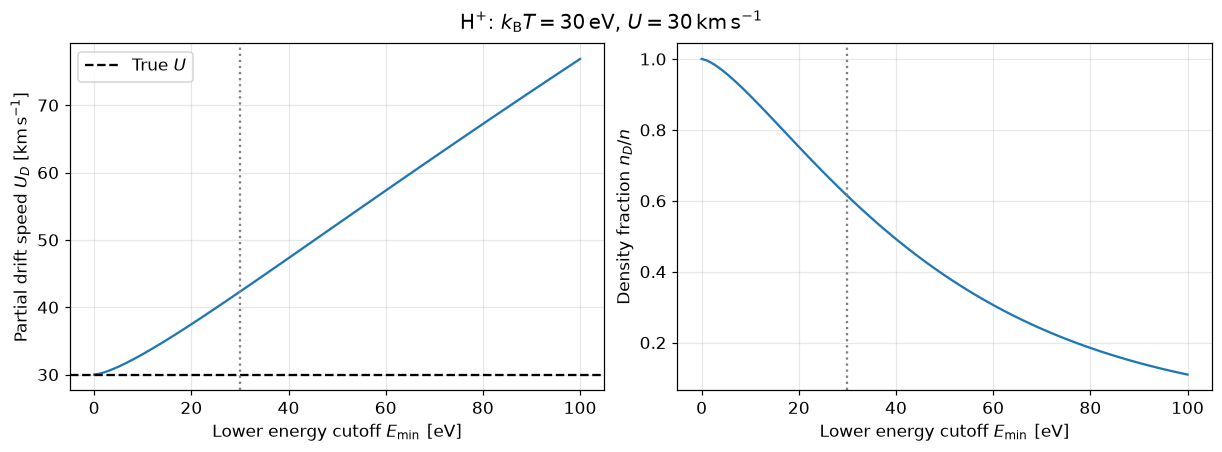

,theta_ev,U_kms,density_fraction,partial_speed_kms,density_quad_error,flux_quad_error,bias_kms,ratio
0,10.0,20.0,0.152985,46.305662,1.107657e-13,1.484443e-14,26.305662,2.315283
1,30.0,30.0,0.613762,42.306846,1.317702e-13,4.661790e-14,12.306846,1.410228
2,100.0,50.0,0.907721,54.496626,1.460118e-13,7.006431e-14,4.496626,1.089933
3,1000.0,100.0,0.996354,100.361581,1.124185e-14,9.048942e-15,0.361581,1.003616
4,10000.0,100.0,0.887251,78.057128,9.850461e-15,5.555176e-16,-21.942872,0.780571


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for theta in [10., 30., 100., 1000.]:
    samples = [partial_moment(theta, speed) for speed in SPEEDS_KMS]
    axes[0].plot(SPEEDS_KMS, [s['partial_speed_kms'] for s in samples], label=rf'$k_{{\mathrm{{B}}}}T={theta:g}\,\mathrm{{eV}}$')
    axes[1].plot(SPEEDS_KMS, [s['density_fraction'] for s in samples], label=rf'$k_{{\mathrm{{B}}}}T={theta:g}\,\mathrm{{eV}}$')
axes[0].plot(SPEEDS_KMS, SPEEDS_KMS, 'k--', label=r'$U_D=U$')
axes[0].set_ylabel(r'Partial drift speed $U_D$ [$\mathrm{km\,s^{-1}}$]')
axes[1].set_ylabel(r'Density fraction $n_D/n$')
for ax in axes:
    ax.set_xlabel(r'True drift speed $U$ [$\mathrm{km\,s^{-1}}$]')
    ax.grid(alpha=.3)
    ax.legend()
fig.savefig(OUTPUT_DIR/'speed_sections.png', dpi=180)
plt.show()

EXAMPLE_THETA_EV = 30.0
EXAMPLE_SPEED_KMS = 30.0
cutoff_rows = []
for emin in np.linspace(0., 100., 101):
    r = partial_moment(EXAMPLE_THETA_EV, EXAMPLE_SPEED_KMS, emin, ENERGY_MAX_EV)
    cutoff_rows.append(dict(emin_ev=emin, **r))
cutoff = pd.DataFrame(cutoff_rows)
cutoff.to_csv(OUTPUT_DIR/'lower_cutoff_scan.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(cutoff.emin_ev, cutoff.partial_speed_kms)
axes[0].axhline(EXAMPLE_SPEED_KMS, color='k', ls='--', label=r'True $U$')
axes[0].set_ylabel(r'Partial drift speed $U_D$ [$\mathrm{km\,s^{-1}}$]')
axes[0].legend()
axes[1].plot(cutoff.emin_ev, cutoff.density_fraction)
axes[1].set_ylabel(r'Density fraction $n_D/n$')
for ax in axes:
    ax.axvline(ENERGY_MIN_EV, color='0.5', ls=':')
    ax.set_xlabel(r'Lower energy cutoff $E_{\min}$ [$\mathrm{eV}$]')
    ax.grid(alpha=.3)
fig.suptitle(rf'$\mathrm{{H}}^{{+}}$: $k_{{\mathrm{{B}}}}T={EXAMPLE_THETA_EV:g}\,\mathrm{{eV}}$, $U={EXAMPLE_SPEED_KMS:g}\,\mathrm{{km\,s^{{-1}}}}$')
fig.savefig(OUTPUT_DIR/'lower_cutoff_scan.png', dpi=180)
plt.show()

examples = []
for theta, speed in [(10., 20.), (30., 30.), (100., 50.), (1000., 100.), (1e4, 100.)]:
    r = partial_moment(theta, speed)
    examples.append(dict(theta_ev=theta, U_kms=speed, **r,
                         bias_kms=r['partial_speed_kms']-speed,
                         ratio=r['partial_speed_kms']/speed))
example_table = pd.DataFrame(examples)
display(example_table)
example_table.to_csv(OUTPUT_DIR/'examples.csv', index=False)


## 圧力テンソルと温度の定義

圧力は、領域 $D$ で求めた平均速度 $\mathbf{U}_D=U_D\hat{\mathbf{z}}$ を中心に計算する。

$$
\mathbf{P}_D=m_{\mathrm{p}}\int_D
(\mathbf{v}-\mathbf{U}_D)(\mathbf{v}-\mathbf{U}_D)
 f(\mathbf{v})\,\mathrm{d}^{3}v,
\qquad
p_D=\frac{1}{3}\operatorname{Tr}\mathbf{P}_D,
\qquad
\theta_D=k_{\mathrm{B}}T_D=\frac{p_D}{n_D}.
$$

括弧の積は外積（dyadic product）を表す。この軸対称モデルでは、非対角成分はゼロ、$P_{D,xx}=P_{D,yy}$ である。$z$ はドリフト軸であり、磁場方向の平行・垂直温度ではない。成分温度を $\theta_{D,z}=P_{D,zz}/n_D$、$\theta_{D,x}=P_{D,xx}/n_D$ と定義する。

元の分布の真値は $\mathbf{P}=n\theta\mathbf{I}$、$p=n\theta$。したがって

$$
\frac{\theta_D}{\theta}=\frac{p_D/p}{n_D/n},
\qquad
\frac{\theta_{D,z}}{\theta_{D,x}}=\frac{P_{D,zz}}{P_{D,xx}}.
$$

温度と圧力は、密度回収率を介して異なる振る舞いを示す。圧力の絶対値には真の密度 $n$ の指定が必要なので、以下では例として $n=1\,\mathrm{cm}^{-3}$ を使う。比はこの値に依存しない。

真の速度 $\mathbf{U}$ を中心にした制限積分は別の量であり、

$$
m_{\mathrm{p}}\int_D(\mathbf{v}-\mathbf{U})(\mathbf{v}-\mathbf{U})f\,\mathrm{d}^{3}v
=\mathbf{P}_D+m_{\mathrm{p}}n_D(\mathbf{U}_D-\mathbf{U})(\mathbf{U}_D-\mathbf{U})
$$

となる。今回は $\mathbf{U}_D$ を中心にした温度・圧力を評価する。`erg_lep_part_products` の温度定義との照合はまだ行っていない。

### 数値計算

$A_2=\int_{-1}^{1}\mu^2\exp(-x^2-a^2+2xa\mu)\,\mathrm{d}\mu$ とすると、$b=2xa>0$ で

$$
\frac{A_2}{A_0}=1-\frac{2L(b)}{b},\qquad
L(b)=\coth b-\frac{1}{b},\qquad
\operatorname{Var}(\mu)=\frac{1}{b^2}-\frac{1}{\sinh^2 b}.
$$

大きなドリフトでの桁落ちを減らすため、$\langle v_z^2\rangle-U_D^2$ を後から差し引く代わりに、$u_D=U_D/v_{\mathrm{th}}$ を用いて中心化した被積分関数を直接積分する。

$$
\begin{aligned}
\frac{P_{D,zz}}{p}&=\frac{4}{\sqrt{\pi}}
\int_{x_{\min}}^{x_{\max}}x^2 A_0\left[(xL-u_D)^2+x^2\operatorname{Var}(\mu)\right]\,\mathrm{d}x,\\
\frac{P_{D,xx}}{p}&=\frac{4}{\sqrt{\pi}}
\int_{x_{\min}}^{x_{\max}}x^4 A_0\frac{L}{b}\,\mathrm{d}x.
\end{aligned}
$$

$b\to0$ では $L/b\to1/3$、$\operatorname{Var}(\mu)\to1/3$。小さい $b$ では級数を使う。密度回収率が `DENSITY_FLOOR` 以下では、速度と同様に温度・圧力の推定値も NaN とする。


In [7]:
REFERENCE_DENSITY_CM3 = 1.0  # 真の密度。絶対圧力の例示にのみ使用する。


def angular_central_statistics(x, a):
    """A0, <mu>, Var(mu), <v_x^2>/v^2 を返す。x方向はドリフト軸に垂直。"""
    a0, _ = angular_moments(x, a)
    b = 2*x*a
    if b < 0.05:
        b2 = b*b
        perp = 1/3 - b2/45 + 2*b2**2/945 - b2**3/4725
        mean = b*perp
        variance = 1/3 - b2/15 + 2*b2**2/189 - b2**3/675
    else:
        mean = 1/np.tanh(b) - 1/b
        perp = mean/b
        em2b = np.exp(-2*b)
        variance = 1/b**2 - 4*em2b/(-np.expm1(-2*b))**2
    return a0, mean, variance, perp


def partial_thermal_moment(theta_ev, speed_kms, emin_ev=ENERGY_MIN_EV,
                           emax_ev=ENERGY_MAX_EV, *, density_cm3=REFERENCE_DENSITY_CM3,
                           epsabs=EPSABS, epsrel=EPSREL, tail_width=TAIL_WIDTH):
    """温度[eV], 圧力[Pa], および真値との比。中心はpartial平均速度。"""
    if not np.isfinite(density_cm3) or density_cm3 <= 0:
        raise ValueError('density_cm3 must be finite and positive')
    velocity = partial_moment(theta_ev, speed_kms, emin_ev, emax_ev,
                              epsabs=epsabs, epsrel=epsrel, tail_width=tail_width)
    nd = velocity['density_fraction']
    p_true = density_cm3*1e6*theta_ev*elementary_charge  # cm^-3 -> m^-3, eV -> J
    fields = ['pressure_z_ratio', 'pressure_x_ratio', 'pressure_ratio',
              'temperature_z_ev', 'temperature_x_ev', 'temperature_ev',
              'temperature_ratio', 'temperature_anisotropy', 'pressure_pa',
              'pressure_z_quad_error', 'pressure_x_quad_error']
    out = dict(**velocity, true_pressure_pa=p_true,
               partial_density_cm3=density_cm3*nd,
               **{name: np.nan for name in fields})
    if nd <= DENSITY_FLOOR:
        return out
    vth = np.sqrt(2*theta_ev*elementary_charge/proton_mass)/1000
    a = speed_kms/vth
    ud = velocity['partial_speed_kms']/vth
    lo = np.sqrt(emin_ev/theta_ev)
    hi = min(np.sqrt(emax_ev/theta_ev), a+tail_width)
    points = sorted({float(t) for t in [1., a-6, a-3, a-1, a, a+1, a+3, a+6]
                     if lo < t < hi})
    opts = dict(epsabs=epsabs, epsrel=epsrel, limit=200, points=points)
    norm = 4/np.sqrt(np.pi)

    def z_integrand(x):
        a0, mean, variance, _ = angular_central_statistics(x, a)
        return norm*x*x*a0*((x*mean-ud)**2 + x*x*variance)

    def x_integrand(x):
        a0, _, _, perp = angular_central_statistics(x, a)
        return norm*x**4*a0*perp

    pz, pz_err = quad(z_integrand, lo, hi, **opts)
    px, px_err = quad(x_integrand, lo, hi, **opts)
    pressure_ratio = (pz+2*px)/3
    out.update(pressure_z_ratio=pz, pressure_x_ratio=px,
               pressure_ratio=pressure_ratio,
               temperature_z_ev=theta_ev*pz/nd,
               temperature_x_ev=theta_ev*px/nd,
               temperature_ev=theta_ev*pressure_ratio/nd,
               temperature_ratio=pressure_ratio/nd,
               temperature_anisotropy=pz/px if px > 0 else np.nan,
               pressure_pa=p_true*pressure_ratio,
               pressure_z_quad_error=pz_err, pressure_x_quad_error=px_err)
    return out


## 温度・圧力の検算

全速度空間で温度・圧力テンソルの真値が戻ること、ドリフトゼロで成分温度が等しいこと、独立な2次元積分との一致、積分精度・裾の打切り位置への収束を確認する。さらに、各圧力成分の非負性と、密度回収率・温度比・圧力比の関係を確認する。

In [8]:
def independent_2d_thermal(theta_ev, speed_kms, order=256):
    """角度の解析式を使わず、partial速度を含めて2D積分する検算。"""
    vth = np.sqrt(2*theta_ev*elementary_charge/proton_mass)/1000
    a = speed_kms/vth
    lo = np.sqrt(ENERGY_MIN_EV/theta_ev)
    hi = min(np.sqrt(ENERGY_MAX_EV/theta_ev), a+TAIL_WIDTH)
    nodes, weights = leggauss(order)
    x = ((hi-lo)/2*nodes+(hi+lo)/2)[:, None]
    mu = nodes[None, :]
    expo = np.exp(-(x-a)**2-2*x*a*(1-mu))
    measure = 2/np.sqrt(np.pi)*(hi-lo)/2*weights[:, None]*weights[None, :]*x*x*expo
    nd = measure.sum()
    ud = (measure*x*mu).sum()/nd
    pz = 2*(measure*(x*mu-ud)**2).sum()
    px = (measure*x*x*(1-mu*mu)).sum()
    return dict(density_fraction=nd, pressure_z_ratio=pz, pressure_x_ratio=px,
                temperature_ev=theta_ev*(pz+2*px)/(3*nd))

thermal_check_rows = []
for theta, speed in [(1., 300.), (10., 0.), (100., 50.), (1000., 300.), (1e4, 50.)]:
    r = partial_thermal_moment(theta, speed, 0., np.inf)
    for key in ['pressure_z_ratio', 'pressure_x_ratio', 'pressure_ratio',
                'temperature_ratio', 'temperature_anisotropy']:
        np.testing.assert_allclose(r[key], 1., rtol=2e-8, atol=1e-10)
    thermal_check_rows.append(dict(check='full domain', theta_ev=theta, U_kms=speed, **r))
for theta in [1., 10., 30., 100., 1000., 1e4]:
    r = partial_thermal_moment(theta, 0.)
    if r['density_fraction'] > DENSITY_FLOOR:
        np.testing.assert_allclose(r['temperature_anisotropy'], 1., rtol=1e-10)
for theta, speed in [(10., 20.), (100., 50.), (1000., 200.)]:
    r = partial_thermal_moment(theta, speed)
    r2 = independent_2d_thermal(theta, speed)
    for key in r2:
        np.testing.assert_allclose(r[key], r2[key], rtol=1e-8, atol=1e-10)
    thermal_check_rows.append(dict(check='independent 2D', theta_ev=theta, U_kms=speed, **r))
for theta, speed in [(1., 20.), (1., 300.), (10., 20.), (100., 50.), (1e4, 300.)]:
    normal = partial_thermal_moment(theta, speed)
    strict = partial_thermal_moment(theta, speed, epsabs=1e-17, epsrel=1e-11, tail_width=16.)
    for key in ['pressure_z_ratio', 'pressure_x_ratio', 'temperature_ev', 'temperature_anisotropy']:
        np.testing.assert_allclose(normal[key], strict[key], rtol=1e-7, atol=1e-10, equal_nan=True)
thermal_checks = pd.DataFrame(thermal_check_rows)
thermal_checks.to_csv(OUTPUT_DIR/'thermal_numerical_checks.csv', index=False)
display(thermal_checks[['check', 'theta_ev', 'U_kms', 'temperature_ratio',
                        'pressure_ratio', 'temperature_anisotropy']])
print('All temperature and pressure numerical checks passed.')


,check,theta_ev,U_kms,temperature_ratio,pressure_ratio,temperature_anisotropy
0,full domain,1.0,300.0,1.000000,1.000000,1.000000
1,full domain,10.0,0.0,1.000000,1.000000,1.000000
2,full domain,100.0,50.0,1.000000,1.000000,1.000000
3,full domain,1000.0,300.0,1.000000,1.000000,1.000000
4,full domain,10000.0,50.0,1.000000,1.000000,1.000000
5,independent 2D,10.0,20.0,2.096931,0.320799,0.717073
6,independent 2D,100.0,50.0,1.082340,0.982463,0.979101
7,independent 2D,1000.0,200.0,1.002669,0.999537,0.998723


All temperature and pressure numerical checks passed.


## 温度・圧力のパラメータ走査

速度検証と同じ温度・流速範囲で、$\theta_D/\theta$、$p_D/p$、$\theta_{D,z}/\theta_{D,x}$ を表示する。圧力比は元の密度 $n$、温度比はpartial密度 $n_D$ を使って定義される。灰色は密度回収率の閾値により評価しない領域を示す。


3111 thermal parameter combinations saved.


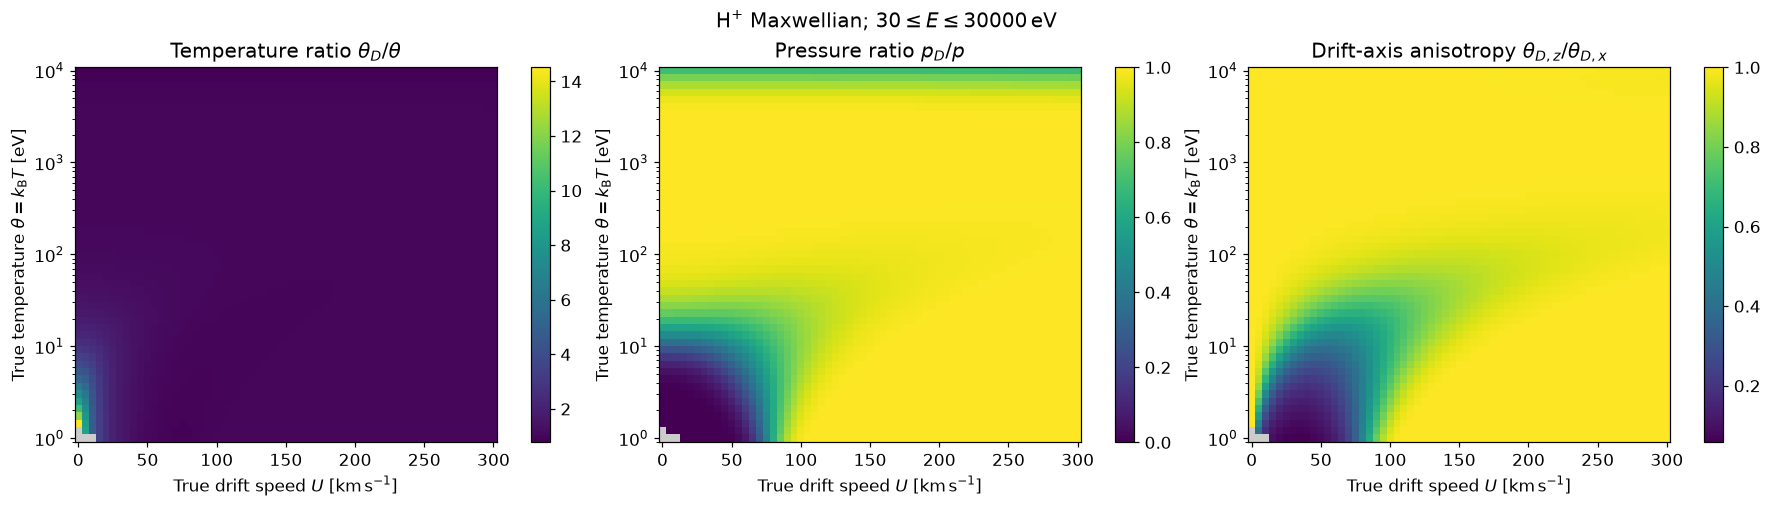

In [9]:
thermal_rows = []
for theta in TEMPERATURES_EV:
    for speed in SPEEDS_KMS:
        r = partial_thermal_moment(theta, speed)
        thermal_rows.append(dict(theta_ev=theta, true_speed_kms=speed, **r))
thermal_results = pd.DataFrame(thermal_rows)
valid = thermal_results['temperature_ratio'].notna()
np.testing.assert_allclose(
    thermal_results.loc[valid, 'pressure_ratio'],
    thermal_results.loc[valid, 'density_fraction']*thermal_results.loc[valid, 'temperature_ratio'],
    rtol=1e-12, atol=1e-14)
for component in ['pressure_z_ratio', 'pressure_x_ratio']:
    values = thermal_results.loc[valid, component]
    assert (values >= 0).all()
    # 全分布の中心圧力から一部を取り出し、partial平均で中心化するため上限は真値。
    assert (values <= 1+1e-8).all()
thermal_results.to_csv(OUTPUT_DIR/'thermal_parameter_scan.csv', index=False)
print(f'{len(thermal_results)} thermal parameter combinations saved.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
fields = [('temperature_ratio', r'Temperature ratio $\theta_D/\theta$', 'viridis', None, None),
          ('pressure_ratio', r'Pressure ratio $p_D/p$', 'viridis', 0., 1.),
          ('temperature_anisotropy', r'Drift-axis anisotropy $\theta_{D,z}/\theta_{D,x}$', 'viridis', None, None)]
for ax, (field, title, cmap_name, vmin, vmax) in zip(axes, fields):
    grid = thermal_results.pivot(index='theta_ev', columns='true_speed_kms', values=field)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('0.8')
    im = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), shading='nearest',
                       cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_yscale('log')
    ax.set_xlabel(r'True drift speed $U$ [$\mathrm{km\,s^{-1}}$]')
    ax.set_ylabel(r'True temperature $\theta=k_{\mathrm{B}}T$ [$\mathrm{eV}$]')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
fig.suptitle(rf'$\mathrm{{H}}^{{+}}$ Maxwellian; ${ENERGY_MIN_EV:g} \leq E \leq {ENERGY_MAX_EV:g}\,\mathrm{{eV}}$')
fig.savefig(OUTPUT_DIR/'thermal_parameter_scan.png', dpi=180)
plt.show()


## 温度・圧力の積分下限への感度と代表値

速度検証と同じ例示条件で積分下限を変える。図では温度と圧力の比を並べ、密度の取りこぼしによる違いを確認する。絶対圧力は指定した真の密度に比例する。


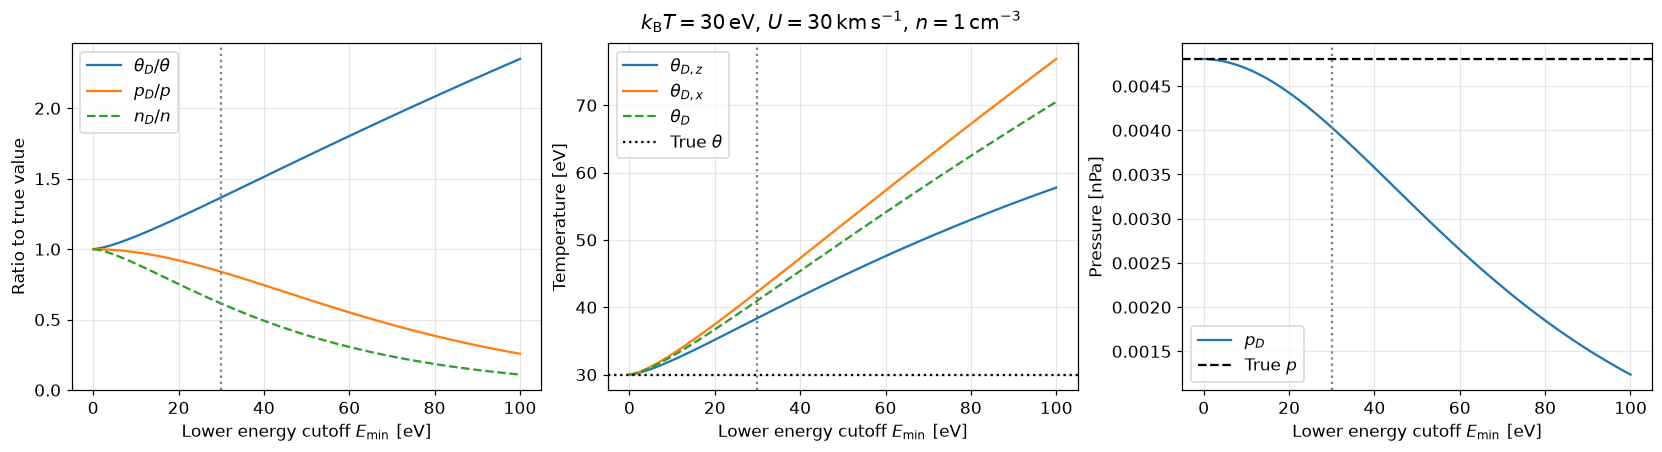

,theta_ev,U_kms,density_fraction,temperature_ev,temperature_ratio,pressure_ratio,temperature_anisotropy,pressure_pa
0,10.0,20.0,0.152985,20.969311,2.096931,0.320799,0.717073,5.139770e-13
1,30.0,30.0,0.613762,40.999960,1.366665,0.838807,0.907328,4.031750e-12
2,100.0,50.0,0.907721,108.233971,1.082340,0.982463,0.979101,1.574079e-11
3,1000.0,100.0,0.996354,1003.491040,1.003491,0.999832,0.999627,1.601908e-10
4,10000.0,100.0,0.887251,7802.520710,0.780252,0.692279,0.998773,1.109154e-09


In [10]:
thermal_cutoff_rows = []
for emin in cutoff['emin_ev']:
    r = partial_thermal_moment(EXAMPLE_THETA_EV, EXAMPLE_SPEED_KMS, emin, ENERGY_MAX_EV)
    thermal_cutoff_rows.append(dict(emin_ev=emin, **r))
thermal_cutoff = pd.DataFrame(thermal_cutoff_rows)
thermal_cutoff.to_csv(OUTPUT_DIR/'thermal_lower_cutoff_scan.csv', index=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].plot(thermal_cutoff.emin_ev, thermal_cutoff.temperature_ratio, label=r'$\theta_D/\theta$')
axes[0].plot(thermal_cutoff.emin_ev, thermal_cutoff.pressure_ratio, label=r'$p_D/p$')
axes[0].plot(thermal_cutoff.emin_ev, thermal_cutoff.density_fraction, ls='--', label=r'$n_D/n$')
axes[0].set_ylabel('Ratio to true value')
axes[1].plot(thermal_cutoff.emin_ev, thermal_cutoff.temperature_z_ev, label=r'$\theta_{D,z}$')
axes[1].plot(thermal_cutoff.emin_ev, thermal_cutoff.temperature_x_ev, label=r'$\theta_{D,x}$')
axes[1].plot(thermal_cutoff.emin_ev, thermal_cutoff.temperature_ev, ls='--', label=r'$\theta_D$')
axes[1].axhline(EXAMPLE_THETA_EV, color='k', ls=':', label=r'True $\theta$')
axes[1].set_ylabel(r'Temperature [$\mathrm{eV}$]')
axes[2].plot(thermal_cutoff.emin_ev, thermal_cutoff.pressure_pa*1e9, label=r'$p_D$')
axes[2].axhline(thermal_cutoff.true_pressure_pa.iloc[0]*1e9, color='k', ls='--', label=r'True $p$')
axes[2].set_ylabel(r'Pressure [$\mathrm{nPa}$]')
for ax in axes:
    ax.axvline(ENERGY_MIN_EV, color='0.5', ls=':')
    ax.set_xlabel(r'Lower energy cutoff $E_{\min}$ [$\mathrm{eV}$]')
    ax.grid(alpha=.3)
    ax.legend()
fig.suptitle(rf'$k_{{\mathrm{{B}}}}T={EXAMPLE_THETA_EV:g}\,\mathrm{{eV}}$, '
             rf'$U={EXAMPLE_SPEED_KMS:g}\,\mathrm{{km\,s^{{-1}}}}$, '
             rf'$n={REFERENCE_DENSITY_CM3:g}\,\mathrm{{cm^{{-3}}}}$')
fig.savefig(OUTPUT_DIR/'thermal_lower_cutoff_scan.png', dpi=180)
plt.show()

thermal_examples = []
for theta, speed in [(10., 20.), (30., 30.), (100., 50.), (1000., 100.), (1e4, 100.)]:
    r = partial_thermal_moment(theta, speed)
    thermal_examples.append(dict(theta_ev=theta, U_kms=speed, **r))
thermal_example_table = pd.DataFrame(thermal_examples)
thermal_example_table.to_csv(OUTPUT_DIR/'thermal_examples.csv', index=False)
display(thermal_example_table[['theta_ev', 'U_kms', 'density_fraction', 'temperature_ev',
                               'temperature_ratio', 'pressure_ratio', 'temperature_anisotropy',
                               'pressure_pa']])


### 温度・圧力の解釈

- $\theta_D$ はpartial平均速度を中心にした2次momentであり、選択された粒子群の温度である。分布全体の温度との一致は保証されない。
- 元の等方的な分布でもエネルギー選択によって成分温度が異なり得る。ここでの異方性はドリフト軸に関するもので、磁場に対する異方性と同一ではない。
- $p_D/p=(n_D/n)(\theta_D/\theta)$ なので、圧力が低下していても温度が上昇することがある。
- 今回の「全立体角・単一分布の制限積分をpartial平均で中心化する」という定義では、各圧力成分は非負で、対応する真の圧力成分以下になる。計数誤差や背景補正を含む観測処理に、そのままこの性質を適用しない。
- 速度だけでなく温度にも偏りがある場合、熱速度、イオン回転半径、プラズマβなどへの影響を、密度・組成の扱いも含めて評価する必要がある。このノートでは研究の最終推定量への伝播はまだ計算していない。


## 研究での解釈と次の検証

- この計算が示すのは、指定した単一Maxwell分布に対するエネルギー制限の偏りである。観測時の真の速度の誤差を直接決めるものではない。
- 密度が欠けても平均速度が常に偏るとは限らない。$U=0$の場合には対称性により速度はゼロのままである。非ゼロの流速では、エネルギー選択が分布のどの部分を除くかによって偏りが生じる。
- このモデルでは真の速度とpartialな速度は同じ軸上にある。異方性、多成分、角度欠測がある場合の方向の誤差は評価していない。
- 既存解析の周波数から波数への換算では、他の量を固定すると $k_\perp\rho_i\propto1/|V_{\mathrm{sys}}|$。ここで計算した $U$ の比を、そのまま $V_{\mathrm{sys}}$ の比として使わない。座標変換・衛星速度処理・垂直成分への射影を適用してから評価する。
- 温度や組成もpartial momentなので、速度だけを置き換えた評価と、他のmomentも同時に変えた評価は区別する。

次の段階は、既知の疑似分布をLEP-iの実ビンに載せて `erg_lep_part_products` の出力と比較すること。その後、注目するtime rangeの実分布からモデルとパラメータ範囲を絞る。未観測の冷たい成分などは追加の仮定として扱い、文献・軌道環境の根拠を付けて範囲を振る。